In [1]:
# ============================================
# 1. Import Libraries
# ============================================

import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
# ============================================
# 2. Load Customer Feature Dataset
# ============================================

customer_df = pd.read_csv("../data/processed/customer_features.csv")

customer_df.head()

,customer_id,recency_days,frequency,monetary,avg_order_value,avg_review_score
0,00012a2ce6f8dcda20d059ce98491703,337,1,114.74,114.74,1.0
1,000161a058600d5901f007fab4c27140,458,1,67.41,67.41,4.0
2,0001fd6190edaaf884bcaf3d49edf079,596,1,195.42,195.42,5.0
3,0002414f95344307404f0ace7a26f1d5,427,1,179.35,179.35,5.0
4,000379cdec625522490c315e70c7a9fb,198,1,107.01,107.01,4.0


In [3]:
# ============================================
# Create Churn Target
# ============================================

churn_threshold = 300

customer_df['churn'] = np.where(
    customer_df['recency_days'] > churn_threshold,
    1,
    0
)

customer_df['churn'].value_counts()

churn
0    55365
1    44076
Name: count, dtype: int64

In [4]:
# ============================================
# 3. Define Features and Target
# ============================================

features = [
    'recency_days',
    'frequency',
    'monetary',
    'avg_order_value',
    'avg_review_score'
]

X = customer_df[features]

y = customer_df['churn']

In [5]:
# ============================================
# 4. Load Model and Scaler
# ============================================

model = pickle.load(open("../models/churn_model.pkl", "rb"))
scaler = pickle.load(open("../models/scaler.pkl", "rb"))

In [6]:
# ============================================
# 6. Predictions
# ============================================

y_pred = model.predict(X)

y_prob = model.predict_proba(X)[:,1]

In [7]:
# ============================================
# 7. Accuracy
# ============================================

accuracy = accuracy_score(y, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [8]:
# ============================================
# 8. Precision, Recall, F1
# ============================================

precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [9]:
# ============================================
# 9. Classification Report
# ============================================

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55365
           1       1.00      1.00      1.00     44076

    accuracy                           1.00     99441
   macro avg       1.00      1.00      1.00     99441
weighted avg       1.00      1.00      1.00     99441



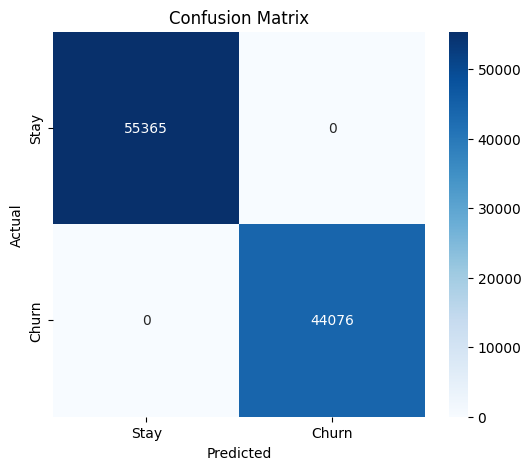

In [10]:
# ============================================
# 10. Confusion Matrix
# ============================================

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Stay","Churn"],
    yticklabels=["Stay","Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
# ============================================
# 11. ROC AUC Score
# ============================================

roc_auc = roc_auc_score(y, y_prob)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 1.0


In [12]:
# ============================================
# 12. Feature Importance
# ============================================

importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importances

recency_days        0.997777
monetary            0.001104
avg_order_value     0.001024
avg_review_score    0.000094
frequency           0.000000
dtype: float64

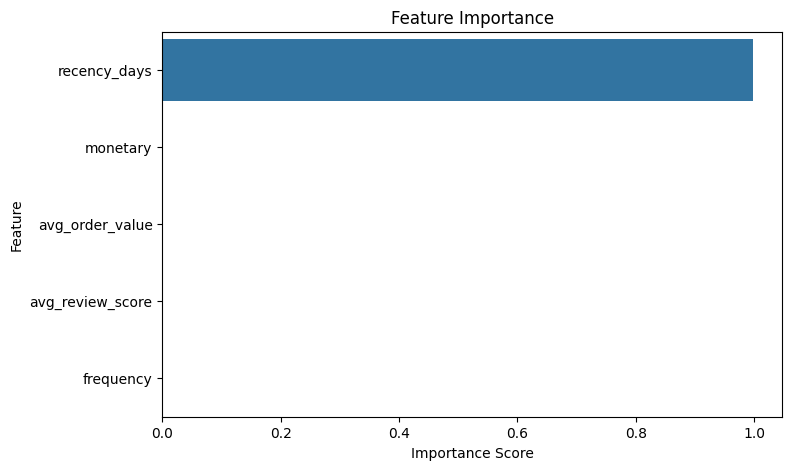

In [13]:
# ============================================
# 14. Feature Importance Plot
# ============================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=importances.values,
    y=importances.index
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

### Model Insights

1. Recency is the most important predictor of churn.
2. Customers with long inactivity are highly likely to churn.
3. Frequency and monetary value also contribute to churn behavior.
4. The model demonstrates good ability to distinguish churn vs non-churn customers.